## 1. Install & Import Dependencies

In [1]:
import os
import glob
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score,
    precision_recall_fscore_support
)
from sklearn.utils.class_weight import compute_class_weight

import joblib

# ── Reproducibility ────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch version : {torch.__version__}")
print(f"Device          : {DEVICE}")

PyTorch version : 2.11.0+cu126
Device          : cuda


## 2. Load CIC-IDS 2017 Dataset



In [ ]:

DATA_DIR = '/home/tanmoyanustup/Documents/dl_project_TanoAnu/cic_ids_2017/'

def load_cicids2017(data_dir):
    csv_files = glob.glob(os.path.join(data_dir, '*.csv'))
    if not csv_files:
        raise FileNotFoundError(
            f"No CSV files found in '{data_dir}'.\n"
            "Download from: https://www.unb.ca/cic/datasets/ids-2017.html"
        )
    print(f"Found {len(csv_files)} CSV file(s):")
    dfs = []
    for f in sorted(csv_files):
        print(f"  Loading: {os.path.basename(f)}")
        dfs.append(pd.read_csv(f, low_memory=False))
    combined = pd.concat(dfs, ignore_index=True)
    print(f"\nTotal records: {len(combined):,}")
    return combined

df = load_cicids2017(DATA_DIR)


Found 8 CSV file(s):
  Loading: Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv
  Loading: Friday-WorkingHours-Morning.pcap_ISCX.csv
  Loading: Monday-WorkingHours.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv
  Loading: Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv
  Loading: Tuesday-WorkingHours.pcap_ISCX.csv
  Loading: Wednesday-workingHours.pcap_ISCX.csv

Total records: 2,830,743


## 3. Data Preprocessing

In [ ]:
df.columns = df.columns.str.strip()
label_col  = 'Label'
print("Label column found:", label_col in df.columns)
print("\nClass distribution (raw):")
print(df[label_col].value_counts())

Label column found: True

Class distribution (raw):
Label
Benign Traffic                    2273097
DoS Attacks                        252661
Port Scanning & Brute Force        172765
DDoS Attacks                       128027
Web-Based Attacks                    2180
Other Exploits & Infiltrations       2013
Name: count, dtype: int64


In [ ]:
# Drop non-numeric / identifier columns 
drop_cols = ['Flow ID', 'Source IP', 'Destination IP',
             'Src IP', 'Dst IP', 'src_ip', 'dst_ip']
drop_cols = [c for c in drop_cols if c in df.columns]
df.drop(columns=drop_cols, inplace=True)
print(f"Dropped: {drop_cols}")

# Handle Inf / NaN 
df.replace([np.inf, -np.inf], np.nan, inplace=True)
before = len(df)
df.dropna(inplace=True)
print(f"Removed {before - len(df):,} rows with NaN/Inf. Remaining: {len(df):,}")

#  Separate features and labels 
X     = df.drop(columns=[LABEL_COL]).select_dtypes(include=[np.number])
y_raw = df[LABEL_COL].str.strip()

print(f"\nFeature matrix : {X.shape}")
print(f"Classes        : {sorted(y_raw.unique())}")

Dropped: []
Removed 2,867 rows with NaN/Inf. Remaining: 2,827,876

Feature matrix : (2827876, 78)
Classes        : ['Benign Traffic', 'DDoS Attacks', 'DoS Attacks', 'Other Exploits & Infiltrations', 'Port Scanning & Brute Force', 'Web-Based Attacks']


In [10]:
df.columns = df.columns.str.strip()
LABEL_COL = 'Label'

print("Raw class distribution:")
print(df[LABEL_COL].value_counts())

Raw class distribution:
Label
Benign Traffic                    2271320
DoS Attacks                        251712
Port Scanning & Brute Force        172636
DDoS Attacks                       128025
Web-Based Attacks                    2180
Other Exploits & Infiltrations       2003
Name: count, dtype: int64


In [11]:
rename_classes = {
    'Web Attack � Brute Force' : 'Brute Force',
    'Web Attack � XSS' : 'XSS',
    'Web Attack � Sql Injection' : 'SQL Injection'

}

df[LABEL_COL] = df[LABEL_COL].map(rename_classes).fillna(df[LABEL_COL])
print(df[LABEL_COL].value_counts())

Label
Benign Traffic                    2271320
DoS Attacks                        251712
Port Scanning & Brute Force        172636
DDoS Attacks                       128025
Web-Based Attacks                    2180
Other Exploits & Infiltrations       2003
Name: count, dtype: int64


In [12]:
label_map = {
    'BENIGN': 'Benign Traffic',
    'DoS Hulk': 'DoS Attacks',
    'DoS GoldenEye': 'DoS Attacks',
    'DoS slowloris': 'DoS Attacks',
    'DoS Slowhttptest': 'DoS Attacks',
    'DDoS': 'DDoS Attacks',
    'PortScan': 'Port Scanning & Brute Force',
    'FTP-Patator': 'Port Scanning & Brute Force',
    'SSH-Patator': 'Port Scanning & Brute Force',
    'Brute Force': 'Web-Based Attacks',
    'XSS': 'Web-Based Attacks',
    'SQL Injection': 'Web-Based Attacks',
    'Bot': 'Other Exploits & Infiltrations',
    'Infiltration': 'Other Exploits & Infiltrations',
    'Heartbleed': 'Other Exploits & Infiltrations'
}
df[LABEL_COL] = df[LABEL_COL].map(label_map).fillna(df[LABEL_COL])

print("Consolidated class distribution:")
print(df[LABEL_COL].value_counts())

Consolidated class distribution:
Label
Benign Traffic                    2271320
DoS Attacks                        251712
Port Scanning & Brute Force        172636
DDoS Attacks                       128025
Web-Based Attacks                    2180
Other Exploits & Infiltrations       2003
Name: count, dtype: int64


In [ ]:


# Calculate the distribution
counts = df[LABEL_COL].value_counts()

# Set plot style
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the bar plot
# We use log=True if the Benign count is significantly higher than others
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis", hue=counts.index, legend=False)

# Formatting
plt.title("Consolidated Class Distribution (NIDS Dataset)", fontsize=14)
plt.xlabel("Traffic Category", fontsize=12)
plt.ylabel("Count (Log Scale)", fontsize=12)
plt.yscale("log")  # Highly recommended for CIC-IDS-2017
plt.xticks(rotation=45, ha='right')

# Add text labels on top of the bars
for i, v in enumerate(counts.values):
    ax.text(i, v, f'{v}', color='black', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:

le        = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
n_classes = len(le.classes_)
print("Label encoding:")
for i, cls in enumerate(le.classes_):
    print(f"  {i}: {cls}")

Label encoding:
  0: Benign Traffic
  1: DDoS Attacks
  2: DoS Attacks
  3: Other Exploits & Infiltrations
  4: Port Scanning & Brute Force
  5: Web-Based Attacks


In [ ]:
# Normalize featurs
scaler     = StandardScaler()
X_scaled   = scaler.fit_transform(X)
n_features = X_scaled.shape[1]
print(f"Normalized features shape: {X_scaled.shape}")

Normalized features shape: (2827876, 78)


In [ ]:


from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=SEED, k_neighbors=3)
X_scaled, y_encoded = sm.fit_resample(X_scaled, y_encoded)
X_scaled = X_scaled.astype(np.float32)

print("After SMOTE:")
unique, counts = np.unique(y_encoded, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]:<30} {c:,}")

After SMOTE:
  Benign Traffic                 2,271,320
  DDoS Attacks                   2,271,320
  DoS Attacks                    2,271,320
  Other Exploits & Infiltrations 2,271,320
  Port Scanning & Brute Force    2,271,320
  Web-Based Attacks              2,271,320


## 4. Sliding Window Construction

Each sample = **10 consecutive flows** → shape `(samples, 10, n_features)`

In [17]:
WINDOW_SIZE = 5

def create_sliding_windows(X, y, window_size):
    """
    Non-overlapping sliding windows.
    Label = majority class within the window.
    """
    X_windows, y_windows = [], []
    for i in range(0, len(X) - window_size + 1, window_size):
        X_windows.append(X[i : i + window_size])
        y_windows.append(np.bincount(y[i : i + window_size]).argmax())
    return np.array(X_windows, dtype=np.float32), np.array(y_windows, dtype=np.int64)

print("Creating sliding windows...")
X_windows, y_windows = create_sliding_windows(X_scaled, y_encoded, WINDOW_SIZE)

print(f"X shape: {X_windows.shape}  →  (samples, timesteps, features)")
print(f"y shape: {y_windows.shape}")
unique, counts = np.unique(y_windows, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {le.classes_[u]}: {c:,}")

Creating sliding windows...
X shape: (2725584, 5, 78)  →  (samples, timesteps, features)
y shape: (2725584,)
  Benign Traffic: 456,444
  DDoS Attacks: 454,266
  DoS Attacks: 453,724
  Other Exploits & Infiltrations: 453,992
  Port Scanning & Brute Force: 453,308
  Web-Based Attacks: 453,850


In [ ]:
# train test val split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_windows, y_windows, test_size=0.30, random_state=SEED, stratify=y_windows
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)
print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

Train: 1,907,908 | Val: 408,838 | Test: 408,838


After SMOTE:
  Benign Traffic                 2,271,320
  DDoS Attacks                   2,271,320
  DoS Attacks                    2,271,320
  Other Exploits & Infiltrations 2,271,320
  Port Scanning & Brute Force    2,271,320
  Web-Based Attacks              2,271,320


In [ ]:

class IDS2017Dataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# ── Weighted sampler to handle class imbalance ─────────────────────────────
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
sample_weights = torch.tensor([class_weights[y] for y in y_train], dtype=torch.float32)
sampler = WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

BATCH_SIZE = 256

train_loader = DataLoader(IDS2017Dataset(X_train, y_train), batch_size=BATCH_SIZE, sampler=sampler)
val_loader   = DataLoader(IDS2017Dataset(X_val,   y_val),   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(IDS2017Dataset(X_test,  y_test),  batch_size=BATCH_SIZE, shuffle=False)

print("DataLoaders ready.")
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

DataLoaders ready.
Train batches: 7453 | Val batches: 1598 | Test batches: 1598


## 5. CNN-LSTM Model Architecture



In [ ]:
class CNNLSTM(nn.Module):
    def __init__(self, n_features, n_classes, window_size=10):
        super(CNNLSTM, self).__init__()

        # CNN block
        # Input: (batch, n_features, window_size)  [channels-first for Conv1d]
        self.cnn = nn.Sequential(
            nn.Conv1d(in_channels=n_features, out_channels=64,  kernel_size=3, padding=1),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Conv1d(in_channels=64,         out_channels=128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            nn.Dropout(p=0.3)
        )

        # Compute LSTM input size after pooling
        # After MaxPool1d(2): timesteps = window_size // 2
        lstm_seq_len = window_size // 2
        lstm_input_size = 128   # CNN output channels

        # lstm Block 
        # Input: (batch, seq_len, lstm_input_size)
        self.lstm = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=128,
            num_layers=2,
            batch_first=True,
            dropout=0.3
        )

        # classifier head
        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=0.4),
            nn.Linear(64, n_classes)
        )

    def forward(self, x):
        # x: (batch, window_size, n_features)

        # Permute for Conv1d: (batch, n_features, window_size)
        x = x.permute(0, 2, 1)

        # CNN feature extraction
        x = self.cnn(x)             # → (batch, 128, window_size//2)

        # Permute for LSTM: (batch, seq_len, 128)
        x = x.permute(0, 2, 1)

        # LSTM temporal modeling
        x, (h_n, c_n) = self.lstm(x)
        x = x[:, -1, :]            # take last timestep → (batch, 128)

        # Classification
        x = self.classifier(x)     # → (batch, n_classes)
        return x


model = CNNLSTM(n_features=n_features, n_classes=n_classes, window_size=WINDOW_SIZE).to(DEVICE)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTrainable parameters: {total_params:,}")

CNNLSTM(
  (cnn): Sequential(
    (0): Conv1d(78, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout(p=0.3, inplace=False)
  )
  (lstm): LSTM(128, 128, num_layers=2, batch_first=True, dropout=0.3)
  (classifier): Sequential(
    (0): Linear(in_features=128, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=64, out_features=6, bias=True)
  )
)

Trainable parameters: 313,094


## 6. Training

In [ ]:
# loss, optimizer, scheduler 
# class weights passed to CrossEntropyLoss for additional imbalance handling
cw_tensor  = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)
criterion  = nn.CrossEntropyLoss(weight=cw_tensor)
optimizer  = optim.Adam(model.parameters(), lr=1e-3)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

EPOCHS       = 50
PATIENCE     = 7
best_val_loss = np.inf
patience_ctr  = 0

train_acc_history, val_acc_history = [], []
train_loss_history, val_loss_history = [], []


def evaluate(loader):
    """Return average loss and accuracy over a DataLoader."""
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            loss    = criterion(outputs, y_batch)
            total_loss += loss.item() * len(y_batch)
            preds   = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
            total   += len(y_batch)
    return total_loss / total, correct / total


print("Starting training...\n")
for epoch in range(1, EPOCHS + 1):
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clipping
        optimizer.step()

        train_loss    += loss.item() * len(y_batch)
        train_correct += (outputs.argmax(dim=1) == y_batch).sum().item()
        train_total   += len(y_batch)

    t_loss = train_loss / train_total
    t_acc  = train_correct / train_total
    v_loss, v_acc = evaluate(val_loader)
    scheduler.step(v_loss)

    train_loss_history.append(t_loss)
    val_loss_history.append(v_loss)
    train_acc_history.append(t_acc)
    val_acc_history.append(v_acc)

    print(f"Epoch [{epoch:02d}/{EPOCHS}]  "
          f"Train Loss: {t_loss:.4f}  Train Acc: {t_acc*100:.2f}%  "
          f"Val Loss: {v_loss:.4f}  Val Acc: {v_acc*100:.2f}%")

    # Early stopping + checkpoint
    if v_loss < best_val_loss:
        best_val_loss = v_loss
        patience_ctr  = 0
        torch.save(model.state_dict(), 'best_cnn_lstm.pt')
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print(f"\nEarly stopping triggered at epoch {epoch}.")
            break

# Load best weights
model.load_state_dict(torch.load('best_cnn_lstm.pt', map_location=DEVICE))
print("\nBest model weights restored.")

Starting training...

Epoch [01/50]  Train Loss: 0.0227  Train Acc: 99.41%  Val Loss: 0.0099  Val Acc: 99.68%
Epoch [02/50]  Train Loss: 0.0105  Train Acc: 99.67%  Val Loss: 0.0080  Val Acc: 99.74%
Epoch [03/50]  Train Loss: 0.0085  Train Acc: 99.73%  Val Loss: 0.0081  Val Acc: 99.72%
Epoch [04/50]  Train Loss: 0.0076  Train Acc: 99.76%  Val Loss: 0.0063  Val Acc: 99.79%
Epoch [05/50]  Train Loss: 0.0068  Train Acc: 99.77%  Val Loss: 0.0074  Val Acc: 99.76%
Epoch [06/50]  Train Loss: 0.0069  Train Acc: 99.77%  Val Loss: 0.0064  Val Acc: 99.79%
Epoch [07/50]  Train Loss: 0.0063  Train Acc: 99.79%  Val Loss: 0.0107  Val Acc: 99.54%
Epoch [08/50]  Train Loss: 0.0061  Train Acc: 99.80%  Val Loss: 0.0060  Val Acc: 99.80%
Epoch [09/50]  Train Loss: 0.0059  Train Acc: 99.80%  Val Loss: 0.0067  Val Acc: 99.79%
Epoch [10/50]  Train Loss: 0.0057  Train Acc: 99.81%  Val Loss: 0.0062  Val Acc: 99.80%
Epoch [11/50]  Train Loss: 0.0055  Train Acc: 99.82%  Val Loss: 0.0356  Val Acc: 99.07%
Epoch [12/

## 7. Evaluation

In [ ]:

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)
        outputs = model(X_batch)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

test_loss, test_acc = evaluate(test_loader)
print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_acc*100:.2f}%")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=le.classes_, digits=4))

print(f"Macro F1    : {f1_score(all_labels, all_preds, average='macro'):.4f}")
print(f"Weighted F1 : {f1_score(all_labels, all_preds, average='weighted'):.4f}")

Test Loss    : 0.0027
Test Accuracy: 99.94%

Classification Report:
                                precision    recall  f1-score   support

                Benign Traffic     0.9986    0.9980    0.9983     68467
                  DDoS Attacks     1.0000    1.0000    1.0000     68140
                   DoS Attacks     0.9994    0.9996    0.9995     68058
Other Exploits & Infiltrations     0.9995    0.9997    0.9996     68099
   Port Scanning & Brute Force     0.9992    0.9993    0.9993     67997
             Web-Based Attacks     0.9998    1.0000    0.9999     68077

                      accuracy                         0.9994    408838
                     macro avg     0.9994    0.9994    0.9994    408838
                  weighted avg     0.9994    0.9994    0.9994    408838

Macro F1    : 0.9994
Weighted F1 : 0.9994


## 8. Visualizations

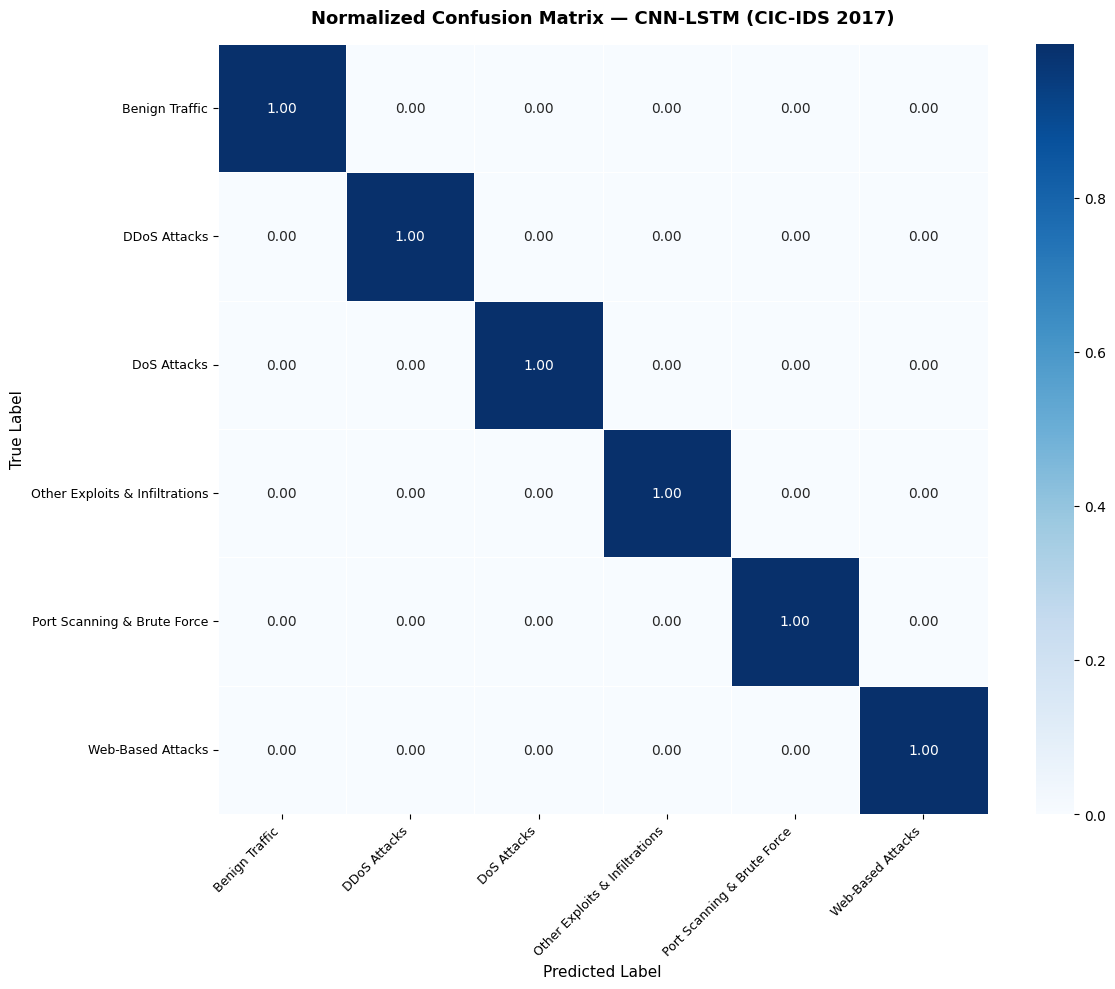

Saved: plot_confusion_matrix.png


In [ ]:
# Confusion Matrix 
cm      = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f',
    xticklabels=le.classes_, yticklabels=le.classes_,
    cmap='Blues', linewidths=0.5, ax=ax
)
ax.set_title('Normalized Confusion Matrix — CNN-LSTM (CIC-IDS 2017)', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=11)
ax.set_ylabel('True Label', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('plot_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: plot_confusion_matrix.png")

## 9. Save Model & Artifacts

In [ ]:
# Save full model
torch.save({
    'model_state_dict' : model.state_dict(),
    'n_features'       : n_features,
    'n_classes'        : n_classes,
    'window_size'      : WINDOW_SIZE,
    'classes'          : list(le.classes_)
}, 'cnn_lstm_cicids2017.pt')
print("Model saved: cnn_lstm_cicids2017.pt")

# Save scaler and label encoder
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(le,     'label_encoder.pkl')
print("Scaler saved: scaler.pkl")
print("Label encoder saved: label_encoder.pkl")

# Save per-class metrics
metrics_df.to_csv('per_class_metrics.csv', index=False)
print("Metrics saved: per_class_metrics.csv")